In [54]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.mast import Observations, Mast
from pprint import pprint
import os
import re
import glob

mast = Mast()

target_name = "NGC 3132"

# Check if FITS files already exist on disk for this target
fits_dir = f"./fits_images/{target_name}"
_skip_query = False
if os.path.isdir(fits_dir):
    existing = glob.glob(os.path.join(fits_dir, "*_i2d.fits"))
    if existing:
        print(f"Found {len(existing)} FITS file(s) on disk in {fits_dir} — skipping MAST query.")
        for p in sorted(existing):
            print(f"  {os.path.basename(p)}")
        _skip_query = True

if not _skip_query:
    obs = Observations.query_object(target_name, radius="0.1 deg")

    miri_obs = obs[
        (obs['instrument_name'] == 'MIRI/IMAGE') &
        (obs['dataproduct_type'] == 'image') &
        (obs['obs_collection'] == 'JWST') &
        (obs['dataRights'] == 'PUBLIC')
    ]
    print(f"MAST query returned {len(miri_obs)} MIRI/IMAGE observations.")


Found 1 FITS file(s) on disk in ./fits_images/NGC 3132 — skipping MAST query.
  jw02733-o002_t001_miri_f770w_i2d.fits


In [55]:
miri_obs

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,wave_min,wave_max,distance
str11,str5,str31,str13,str13,str17,str16,str63,str93,str58,float64,float64,str10,str30,int64,float64,float64,float64,str16,float64,float64,str99,float64,str13,str13,int64,str2105,str178,str179,str6,bool,float64,str9,float64,float64,float64
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1130W,INFRARED,M-16,ISM; Molecular clouds; Nebulae; Protostars,jw02739-o002_t001_miri_f1130w,274.72990744802155,-13.851719802498055,image,"Pontoppidan, Klaus M.",3,59821.607298020834,59821.87122202546,4095.972000000001,INFRARED,10950.0,11650.0,JWST Cycle 1 Outreach Campaign,59883.57043972,2739,DD,--,POLYGON 274.698149359 -13.804083586 274.763358622 -13.812116075 274.754163878 -13.882562849 274.688935174 -13.874527927,mast:JWST/product/jw02739-o002_t001_miri_f1130w_i2d.jpg,mast:JWST/product/jw02739-o002_t001_miri_f1130w_i2d.fits,PUBLIC,False,nan,90712437,10950.0,11650.0,56.137291124426646
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,M-16,ISM; Molecular clouds; Nebulae; Protostars,jw02739-o002_t001_miri_f1500w,274.7299074480236,-13.851719802515994,image,"Pontoppidan, Klaus M.",3,59821.62226561343,59821.886350162036,4295.772000000004,INFRARED,13500.0,16500.0,JWST Cycle 1 Outreach Campaign,59883.57043972,2739,DD,--,POLYGON 274.698142777 -13.804098367 274.763352036 -13.81213091 274.75415723 -13.882577676 274.688928529 -13.874542699,mast:JWST/product/jw02739-o002_t001_miri_f1500w_i2d.jpg,mast:JWST/product/jw02739-o002_t001_miri_f1500w_i2d.fits,PUBLIC,False,nan,90746256,13500.0,16500.0,56.1640043428285
science,JWST,CALJWST,MIRI/IMAGE,JWST,F770W,INFRARED,M-16,ISM; Molecular clouds; Nebulae; Protostars,jw02739-o002_t001_miri_f770w,274.72990744801933,-13.851719802479229,image,"Pontoppidan, Klaus M.",3,59821.591624166664,59821.85577241898,4295.772000000004,INFRARED,6600.0,8800.0,JWST Cycle 1 Outreach Campaign,59883.57043972,2739,DD,--,POLYGON 274.698166766 -13.804090515 274.763376006 -13.812123204 274.754181032 -13.882569951 274.688952351 -13.874534828,mast:JWST/product/jw02739-o002_t001_miri_f770w_i2d.jpg,mast:JWST/product/jw02739-o002_t001_miri_f770w_i2d.fits,PUBLIC,False,nan,90712305,6600.0,8800.0,56.19510489701449
calibration,JWST,CALJWST,MIRI/IMAGE,JWST,OPAQUE,INFRARED,UNKNOWN,--,jw01517005001_02201_00001_mirimage,274.77746873941084,-13.732937935807914,image,"Morrison, Jane",2,59824.876667847224,59824.88119454861,391.107,INFRARED,nan,nan,CAL-MIRI-001 Read Noise and Dark Current Monitoring,59825.93817119,1517,CAL,--,POLYGON 274.768494925 -13.739773676 274.770499673 -13.724125196 274.786495256 -13.726154407 274.784558665 -13.741742529,mast:JWST/product/jw01517005001_02201_00001_mirimage_dark.jpg,--,PUBLIC,False,nan,90863116,nan,nan,338.47924374279233


In [56]:
target_filters = ['F770W', 'F1500W', 'F2550W']

if _skip_query:
    # Already have files on disk — detect which filters are available
    for f in target_filters:
        matches = [p for p in existing if f"_f{f[1:].lower()}" in os.path.basename(p).lower()]
        status = "found on disk" if matches else "MISSING"
        print(f"  {f}: {status}")
    print("\nSkipped MAST filter step — using local files.")
else:
    filtered_by_filter = {}
    for f in target_filters:
        filtered_by_filter[f] = miri_obs[miri_obs['filters'] == f]

    for f, data in filtered_by_filter.items():
        print(f"\n=== Filter: {f} ===")
        print(f"Count: {len(data)}")
        for row in data:
            print(f"  obs_id: {row['obs_id']} | filters: {row['filters']} | t_exptime: {row['t_exptime']}")

    from astropy.table import vstack
    all_filtered = vstack([filtered_by_filter[f] for f in target_filters if len(filtered_by_filter[f]) > 0])
    print(f"\nTotal across all 3 filters: {len(all_filtered)}")


  F770W: found on disk
  F1500W: MISSING
  F2550W: MISSING

Skipped MAST filter step — using local files.


In [57]:
if _skip_query:
    print(f"All files already on disk in {fits_dir} — nothing to download.")
else:
    for f in target_filters:
        filter_obs = all_filtered[all_filtered['filters'] == f]

        if len(filter_obs) == 0:
            print(f"No observations found for filter {f}, skipping...")
            continue

        first = filter_obs[0]
        dataURL = first['dataURL']

        if not dataURL:
            print(f"No dataURL for filter {f}, skipping...")
            continue

        save_dir = f"./fits_images/{target_name}"
        os.makedirs(save_dir, exist_ok=True)

        filename = dataURL.split("/")[-1]
        local_path = f"{save_dir}/{filename}"

        if os.path.exists(local_path):
            print(f"  Already exists, skipping: {local_path}")
            continue

        print(f"Downloading {f}: {filename}")
        Observations.download_file(dataURL, local_path=local_path)
        print(f"  Saved to {local_path}")

# Save config so False_color.ipynb knows which target/filters to use
import json
config = {"target_name": target_name, "target_filters": target_filters}
with open("target_config.json", "w") as cfg:
    json.dump(config, cfg)
print(f"\nSaved target_config.json: {config}")

All files already on disk in ./fits_images/NGC 3132 — nothing to download.

Saved target_config.json: {'target_name': 'NGC 3132', 'target_filters': ['F770W', 'F1500W', 'F2550W']}


File not found for filter F770W: ./fits_images/NGC 3132/jw02739-o002_t001_miri_f770w_i2d.fits
File not found for filter F1500W: ./fits_images/NGC 3132/jw02739-o002_t001_miri_f1500w_i2d.fits
No observations found for filter F2550W, skipping...


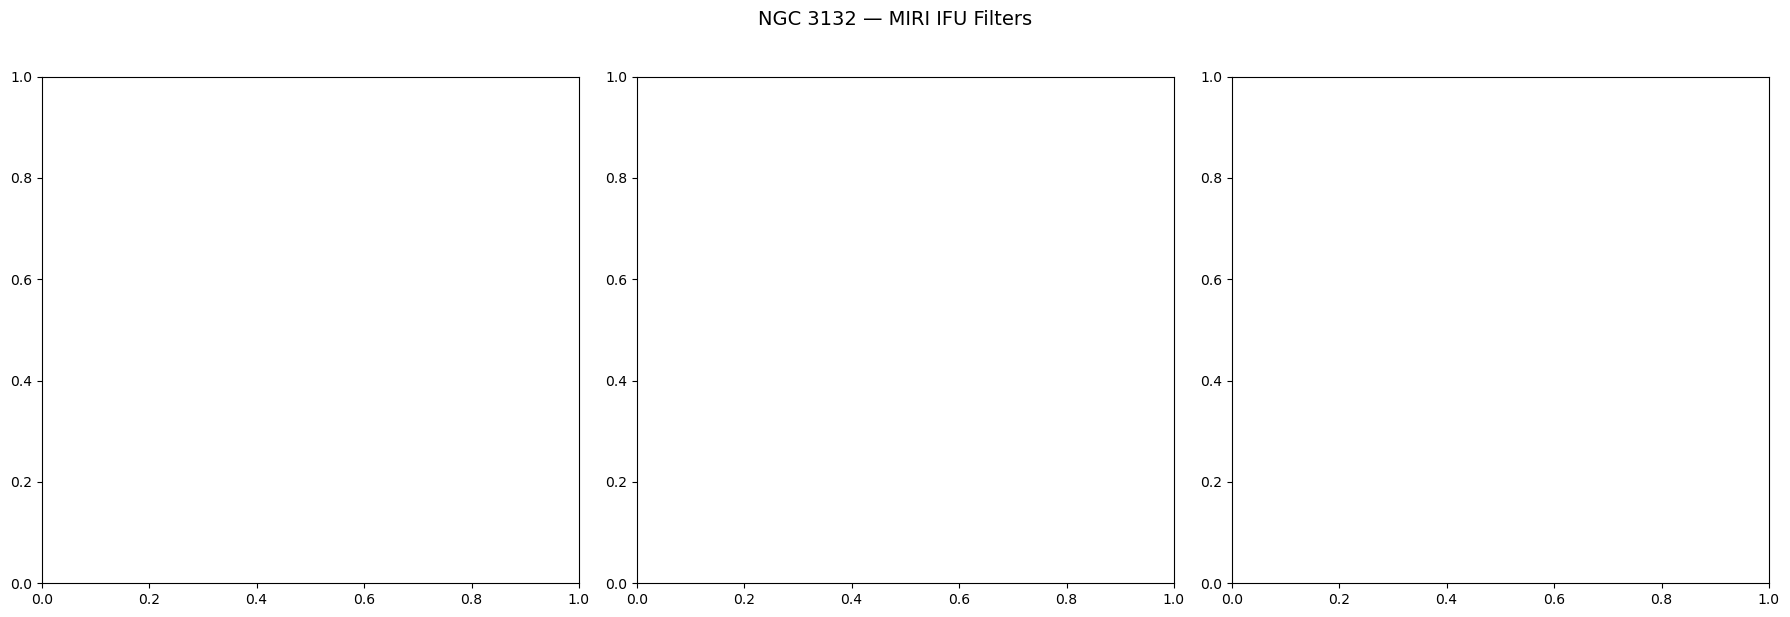

In [59]:
# Auto-discover local FITS files for plotting
import re as _re
local_fits = {}
for fpath in sorted(glob.glob(os.path.join(f"./fits_images/{target_name}", "*_i2d.fits"))):
    m = _re.search(r"_f(\d+w)", os.path.basename(fpath).lower())
    if m:
        filt = f"F{m.group(1).upper()}"
        if filt in target_filters:
            local_fits[filt] = fpath

found_filters = [f for f in target_filters if f in local_fits]
n_panels = max(len(found_filters), 1)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6), squeeze=False)
axes = axes[0]

for i, f in enumerate(found_filters):
    local_path = local_fits[f]
    hdul = fits.open(local_path)

    try:
        cube = hdul['SCI'].data
    except KeyError:
        cube = hdul[1].data

    cube = np.squeeze(cube)

    if cube.ndim == 3:
        image = np.nansum(cube, axis=0)
    elif cube.ndim == 2:
        image = cube
    else:
        print(f"Cannot handle shape {cube.shape} for filter {f}, skipping...")
        hdul.close()
        continue

    image = np.where(image <= 0, np.nan, image)
    vmin = np.nanpercentile(image, 5)
    vmax = np.nanpercentile(image, 99)
    vmin = max(vmin, 1e-10)
    if vmin >= vmax:
        vmax = vmin * 10

    ax = axes[i]
    im = ax.imshow(
        image, origin='lower', cmap='inferno',
        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    )
    ax.set_title(f"{target_name} — {f}", fontsize=12)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.colorbar(im, ax=ax, label="Flux")
    hdul.close()

# Hide unused axes
for j in range(len(found_filters), len(axes)):
    axes[j].set_visible(False)

if not found_filters:
    print(f"No FITS files found for {target_name} with filters {target_filters}")

plt.suptitle(f"{target_name} — MIRI Filters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()